In [12]:
# ========================================================================
# SUPRESIÓN DE WARNINGS Y OPTIMIZACIÓN PARA CPU
# ========================================================================
import os
import warnings
warnings.filterwarnings('ignore')

# Suprimir warnings de TensorFlow y forzar compatibilidad
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Solo errores críticos
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Desactivar oneDNN (menos warnings)
os.environ['TF_USE_LEGACY_KERAS'] = '1'    # Evita fallos de compatibilidad HF/TF en entornos modernos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, cohen_kappa_score
import sys

# Importar Keras para la red neuronal con Dropout y BatchNormalization
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Para Transformers (BETO) -> ¡IMPORTANTE! Usamos PyTorch en lugar de la versión TF
import torch
# Definir el dispositivo (usará GPU si está disponible, si no, CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Trabajando con: {device}")
from transformers import AutoTokenizer, AutoModel
import tensorflow as tf

# Para SMOTE y desbalanceo
from imblearn.over_sampling import SMOTE

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Todas las librerías importadas correctamente")

Trabajando con: cpu
✓ Todas las librerías importadas correctamente


In [13]:
# ========================================================================
# VERIFICACIÓN COMPLETA DE DEPENDENCIAS
# ========================================================================
import sys

required_packages = {
    'pandas': ('Manipulación de datos', 'pip install pandas'),
    'numpy': ('Computación numérica', 'pip install numpy'),
    'sklearn': ('Machine Learning (scikit-learn)', 'pip install scikit-learn'),
    'tensorflow': ('Deep Learning', 'pip install tensorflow'),
    'transformers': ('BETO y modelos Transformer', 'pip install transformers'),
    'torch': ('Backend para Transformers ⭐ CRÍTICO', 'pip install torch'),
    'imblearn': ('SMOTE para desbalanceo (imbalanced-learn)', 'pip install imbalanced-learn'),
    'nltk': ('Procesamiento de lenguaje natural', 'pip install nltk')
}

print("="*80)
print("VERIFICACIÓN DE DEPENDENCIAS INSTALADAS")
print("="*80)

missing_packages = []
installed_packages = []

for package, (description, install_cmd) in required_packages.items():
    try:
        __import__(package)
        installed_packages.append(package)
        status = "✓"
        if package == 'torch':
            status = "✓ ⭐"
        print(f"{status} {package:20s} - {description}")
    except ImportError:
        print(f"✗ {package:20s} - {description} [NO INSTALADO]")
        print(f"  └─ Ejecuta: {install_cmd}")
        missing_packages.append((package, install_cmd))

print("\n" + "="*80)

if missing_packages:
    print(f"\n⚠️  PAQUETES FALTANTES ({len(missing_packages)}):\n")
    for package, install_cmd in missing_packages:
        print(f"  • {package:20s} → {install_cmd}")
    
    print(f"\n💡 SOLUCIÓN RÁPIDA:")
    print(f"  pip install {' '.join([p[0] for p in missing_packages])}")
    
    if any(p[0] == 'torch' for p in missing_packages):
        print(f"\n🔴 CRÍTICO: PyTorch no está instalado")
        print(f"  Sin PyTorch, 'transformers' no puede cargar modelos BETO")
        print(f"  Ejecuta:")
        print(f"    pip install --no-cache-dir torch")
        print(f"  (Primera vez: ~5-10 minutos, ~300-500MB)")
    
    sys.exit(1)
else:
    print(f"\n✅ TODAS LAS DEPENDENCIAS INSTALADAS CORRECTAMENTE ({len(installed_packages)})")
    print(f"\nPaquetes instalados: {', '.join(installed_packages)}")

print("="*80 + "\n")


VERIFICACIÓN DE DEPENDENCIAS INSTALADAS
✓ pandas               - Manipulación de datos
✓ numpy                - Computación numérica
✓ sklearn              - Machine Learning (scikit-learn)
✓ tensorflow           - Deep Learning
✓ transformers         - BETO y modelos Transformer
✓ ⭐ torch                - Backend para Transformers ⭐ CRÍTICO
✓ imblearn             - SMOTE para desbalanceo (imbalanced-learn)
✓ nltk                 - Procesamiento de lenguaje natural


✅ TODAS LAS DEPENDENCIAS INSTALADAS CORRECTAMENTE (8)

Paquetes instalados: pandas, numpy, sklearn, tensorflow, transformers, torch, imblearn, nltk



In [14]:
# Cargar el dataset
import os
df = pd.read_csv('incidencias.csv')

print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())

# Asegurarnos de que no hay nulos en los campos que nos importan
df = df.dropna(subset=['description', 'categoria', 'urgencia'])

# Verificar distribución de clases
print("\nDistribución de clases (urgencias):")
print(df['urgencia'].value_counts().sort_index())


Forma del dataset: (1000, 11)

Primeras filas:


,nombre,apellidos,nif,telefono,email,categoria,description,urgencia,fecha,direccion_persona,ubicacion_incidencia
0,Rosa,Núñez Rodríguez,45167429Y,931315752,rosa_nunez26@yahoo.es,Otros,Pintada en forma de rótulos obscenos en la par...,1,2026-01-01T15:52:55+01:00,"Calle Sierpe 106, 5ºA, 18004 Granada","37.176511, -3.588882 - Bajo la marquesina del ..."
1,Alberto,González García,59304412Q,983389471,alberto_gonzalez23@live.com,Limpieza,Hay papeles de caramelos y bolsas de plástico ...,1,2026-01-01T16:47:58+01:00,"Calle Elvira 66, 3ºB, 18014 Granada","37.180986, -3.589903 - Frente a la farmacia"
2,Javier,Marín López,21500031E,985590542,javier_marin33@live.com,Limpieza,El contenedor de reciclaje en Plazuela de Faja...,2,2026-01-01T20:58:51+01:00,"Calle Gonzalo Gallas 29, 3ºB, 18006 Granada","37.195520, -3.616094 - En la rotonda"
3,Josefa,Cortés Martínez,67375010Y,773400788,jcortes939@gmail.com,Limpieza,Hay basura acumulada hace 4 días en la calle D...,3,2026-01-01T21:26:04+01:00,"Calle Gonzalo Gallas 84, 4ºB, 18009 Granada","37.167973, -3.593403 - Frente a la farmacia"
4,Rocío,Navarro Guerrero,71422036K,761307077,rocionavarro762@gmail.com,Parques y Jardines,El cesped del parque de la Virgen del Carmen e...,1,2026-01-02T09:19:32+01:00,"Paseo de la Bomba 26, 3ºC, 18011 Granada","37.190636, -3.596631 - Junto al centro de salud"



Distribución de clases (urgencias):
urgencia
1    226
2    221
3    209
4    173
5    171
Name: count, dtype: int64


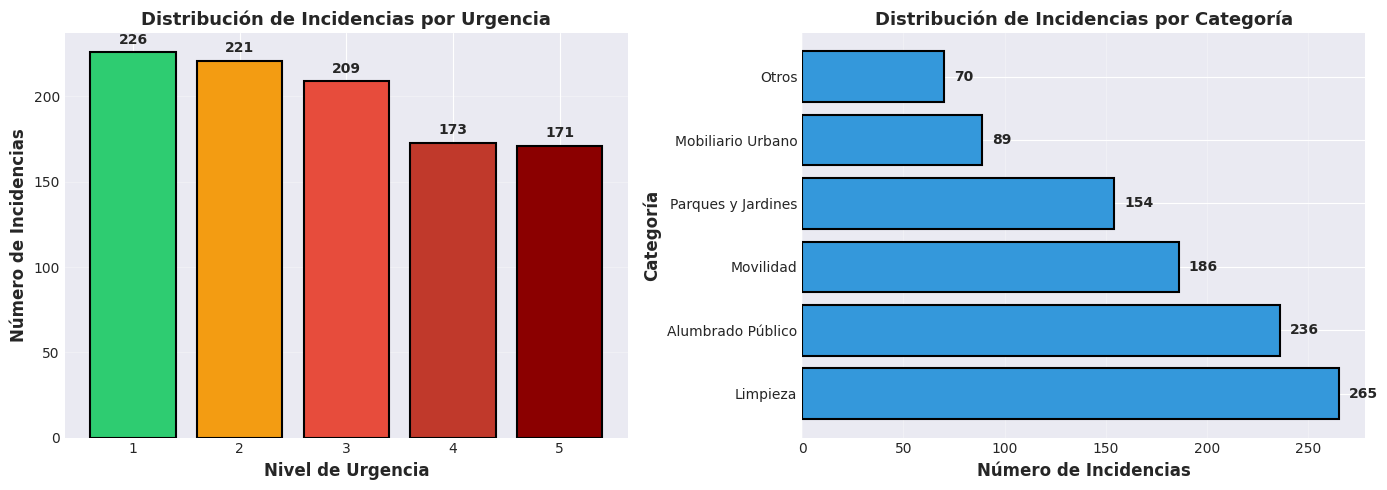


TABLA CRUZADA: URGENCIA vs CATEGORÍA
categoria  Alumbrado Público  Limpieza  Mobiliario Urbano  Movilidad  Otros  \
urgencia                                                                      
1                         53        67                 19         45      9   
2                         51        60                 19         41     19   
3                         44        55                 17         40     19   
4                         41        42                 18         28     13   
5                         47        41                 16         32     10   
All                      236       265                 89        186     70   

categoria  Parques y Jardines   All  
urgencia                             
1                          33   226  
2                          31   221  
3                          34   209  
4                          31   173  
5                          25   171  
All                       154  1000  


In [15]:
# --- VISUALIZACIÓN DE DISTRIBUCIÓN DE INCIDENCIAS ---
# Analizar distribución por urgencia y categoría ANTES de procesar datos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución por Urgencia
urgencia_counts = df['urgencia'].value_counts().sort_index()
colors_urgencia = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b', '#8b0000']
axes[0].bar(urgencia_counts.index, urgencia_counts.values, color=colors_urgencia, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Nivel de Urgencia', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Incidencias', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Incidencias por Urgencia', fontsize=13, fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(urgencia_counts.values):
    axes[0].text(urgencia_counts.index[i], v + 5, str(v), ha='center', fontweight='bold')

# 2. Distribución por Categoría
categoria_counts = df['categoria'].value_counts()
axes[1].barh(categoria_counts.index, categoria_counts.values, color='#3498db', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Número de Incidencias', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Categoría', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución de Incidencias por Categoría', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(categoria_counts.values):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla cruzada de urgencia vs categoría
print("\n" + "="*70)
print("TABLA CRUZADA: URGENCIA vs CATEGORÍA")
print("="*70)
crosstab = pd.crosstab(df['urgencia'], df['categoria'], margins=True)
print(crosstab)

In [16]:
# --- PREPARACIÓN DE DATOS PARA RED NEURONAL (CLASIFICACIÓN MULTICLASE) ---

# Importar stopwords en español de NLTK
import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words_spanish = list(stopwords.words('spanish'))

# ========================================================================
# MEJORA 2: PROCESAMIENTO DE TEXTO CON TRANSFORMERS (BETO)
# ========================================================================
print("\n" + "="*80)
print("MEJORA 2: EXTRAYENDO EMBEDDINGS CON BETO (BERT EN ESPAÑOL)")
print("="*80)

# Cargar el tokenizador y modelo BETO pre-entrenado
# Optimizado para CPU con device_map automático
model_name = "dccuchile/bert-base-spanish-wwm-uncased"

print(f"Descargando modelo: {model_name}")
print("  (Primera ejecución: ~500MB, ~2-3 minutos)")

try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    beto_model = AutoModel.from_pretrained(model_name).to(device)
    print(f"✓ Modelo BETO cargado correctamente")
    print(f"✓ Dimensión de embeddings: {beto_model.config.hidden_size}")
except Exception as e:
    print(f"⚠ Error al cargar BETO: {e}")
    print(f"  Asegúrate de que PyTorch está instalado: pip install torch")
    raise

def obtener_embeddings_beto(textos, batch_size=8):
    beto_model.eval() # Poner el modelo en modo evaluación
    total_textos = len(textos)
    embeddings = []
    
    print(f"Generando embeddings para {total_textos} textos...")
    
    for i in range(0, total_textos, batch_size):
        batch_textos = textos[i:i+batch_size]
        
        # CAMBIO: Usamos return_tensors='pt' (PyTorch)
        inputs = tokenizer(
            batch_textos,
            truncation=True,
            max_length=128,
            padding='max_length',
            return_tensors='pt' 
        ).to(device)
        
        with torch.no_grad(): # No necesitamos calcular gradientes
            outputs = beto_model(**inputs)
            # Extraemos el vector [CLS] (representación global de la frase)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(batch_embeddings)
        
        if (i + batch_size) % 40 == 0:
            print(f"  Procesados: {min(i + batch_size, total_textos)}/{total_textos}")
            
    return np.vstack(embeddings)

# Obtener embeddings para todas las descripciones
X_text = df['description'].astype(str).values
X_text_beto = obtener_embeddings_beto(X_text.tolist(), batch_size=8)

print(f"\n✓ Dimensión final de embeddings BETO: {X_text_beto.shape}")

# ========================================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ========================================================================
X_cat = df[['categoria']].copy()
X_cat_encoded_df = pd.get_dummies(X_cat, columns=['categoria'], drop_first=True)
expected_cat_cols = X_cat_encoded_df.columns
X_cat_encoded = X_cat_encoded_df.values

# Concatenar embeddings BETO + características categóricas
X = np.hstack((X_text_beto, X_cat_encoded))

# ========================================================================
# MEJORA 3: CONVERTIR A PROBLEMA DE CLASIFICACIÓN MULTICLASE
# ========================================================================
# La urgencia es ahora la variable objetivo (1, 2, 3, 4, 5)
y = df['urgencia'].astype(int).values - 1  # Convertir a índices 0-4 para categorical_crossentropy

print(f"\n✓ Configuración para CLASIFICACIÓN MULTICLASE (5 clases)")
print(f"  Variable objetivo (y): {np.unique(y)} (clases 0-4, correspondientes a urgencias 1-5)")

# ========================================================================
# MEJORA 4: GESTIÓN DEL DESBALANCEO CON SMOTE Y CLASS_WEIGHT
# ========================================================================
print("\n" + "="*80)
print("MEJORA 4: GESTIONANDO DESBALANCEO DE CLASES")
print("="*80)

# Dividir ANTES de aplicar SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nAntes de SMOTE:")
print(f"  Train - Distribución de clases: {np.bincount(y_train)}")
print(f"  Test - Distribución de clases: {np.bincount(y_test)}")

# Aplicar SMOTE solo en el conjunto de entrenamiento
smote = SMOTE(random_state=42, k_neighbors=3)  # Reducido a 3 para datasets pequeños
try:
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    print(f"\n✓ SMOTE aplicado exitosamente")
    print(f"Después de SMOTE:")
    print(f"  Train - Distribución de clases: {np.bincount(y_train_resampled)}")
except Exception as e:
    print(f"\n⚠ SMOTE no pudo aplicarse: {e}")
    print(f"  Usando dataset original sin SMOTE")
    X_train_resampled, y_train_resampled = X_train, y_train

# Calcular class_weight para penalizar errores en clases minoritarias
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_resampled),
    y=y_train_resampled
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"\n✓ Class weights calculados: {class_weight_dict}")

# --- NORMALIZACIÓN DE DATOS ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Datos normalizados")
print(f"  Dimensión final X_train: {X_train_scaled.shape}")
print(f"  Dimensión final X_test: {X_test_scaled.shape}")



MEJORA 2: EXTRAYENDO EMBEDDINGS CON BETO (BERT EN ESPAÑOL)
Descargando modelo: dccuchile/bert-base-spanish-wwm-uncased
  (Primera ejecución: ~500MB, ~2-3 minutos)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 20692.12it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the check

✓ Modelo BETO cargado correctamente
✓ Dimensión de embeddings: 768
Generando embeddings para 1000 textos...
  Procesados: 40/1000
  Procesados: 80/1000
  Procesados: 120/1000
  Procesados: 160/1000
  Procesados: 200/1000
  Procesados: 240/1000
  Procesados: 280/1000
  Procesados: 320/1000
  Procesados: 360/1000
  Procesados: 400/1000
  Procesados: 440/1000
  Procesados: 480/1000
  Procesados: 520/1000
  Procesados: 560/1000
  Procesados: 600/1000
  Procesados: 640/1000
  Procesados: 680/1000
  Procesados: 720/1000
  Procesados: 760/1000
  Procesados: 800/1000
  Procesados: 840/1000
  Procesados: 880/1000
  Procesados: 920/1000
  Procesados: 960/1000
  Procesados: 1000/1000

✓ Dimensión final de embeddings BETO: (1000, 768)

✓ Configuración para CLASIFICACIÓN MULTICLASE (5 clases)
  Variable objetivo (y): [0 1 2 3 4] (clases 0-4, correspondientes a urgencias 1-5)

MEJORA 4: GESTIONANDO DESBALANCEO DE CLASES

Antes de SMOTE:
  Train - Distribución de clases: [181 177 167 138 137]
  Test 

In [20]:
# ========================================================================
# MEJORA 1 & 5: ARQUITECTURA MEJORADA CON BATCH NORMALIZATION Y CALLBACKS
# ========================================================================
print("\n" + "="*80)
print("MEJORA 1 & 5: ARQUITECTURA NEURONAL CON BATCH NORMALIZATION")
print("="*80)

# Configurar TensorFlow para usar CPU eficientemente
tf.config.threading.set_inter_op_parallelism_threads(4)
tf.config.threading.set_intra_op_parallelism_threads(4)

# MEJORA 1: Cambiar capa de salida de sigmoid a softmax (multiclase) 
# MEJORA 5: Agregar BatchNormalization y callbacks avanzados

nn_model = models.Sequential([
    layers.Dense(256, kernel_regularizer=l2(0.001), input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    
    layers.Dense(128, kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    
    layers.Dense(64, kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    
    layers.Dense(32, kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    
    # MEJORA 1: Salida multiclase (5 neuronas) con softmax
    layers.Dense(5, activation='softmax')
])

# Compilar modelo con función de pérdida para multiclase
nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*80)
print("ARQUITECTURA DE RED NEURONAL (CLASIFICACIÓN MULTICLASE)")
print("="*80)
nn_model.summary()

# ========================================================================
# MEJORA 5: CALLBACKS AVANZADOS PARA ENTRENAMIENTO
# ========================================================================
print("\n" + "="*80)
print("MEJORA 5: CONFIGURANDO CALLBACKS AVANZADOS")
print("="*80)

# Early Stopping: Detiene el entrenamiento si val_loss no mejora
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Reduce el learning rate si val_loss se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

print("✓ EarlyStopping configurado (patience=20)")
print("✓ ReduceLROnPlateau configurado (factor=0.5, patience=10)")

# --- ENTRENAR RED NEURONAL CON CLASS_WEIGHT ---
print("\n" + "="*80)
print("ENTRENANDO MODELO CON CLASS_WEIGHT Y CALLBACKS")
print("="*80)
print("⏱️  Tiempo estimado: 3-5 minutos en CPU")

y_train_keras = y_train_resampled
y_test_keras = y_test

history = nn_model.fit(
    X_train_scaled, y_train_keras,
    validation_data=(X_test_scaled, y_test_keras),
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,  # MEJORA 4: Penalizar clases minoritarias
    callbacks=[early_stop, reduce_lr],  # MEJORA 5: Callbacks avanzados
    verbose=1
)

print("\n✓ Red Neuronal entrenada exitosamente")
print(f"  Épocas completadas: {len(history.history['loss'])}")
print(f"  Mejor pérdida de validación: {min(history.history['val_loss']):.4f}")



MEJORA 1 & 5: ARQUITECTURA NEURONAL CON BATCH NORMALIZATION

ARQUITECTURA DE RED NEURONAL (CLASIFICACIÓN MULTICLASE)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,461 (951.02 KB)

 Trainable params: 242,501 (947.27 KB)

 Non-trainable params: 960 (3.75 KB)


MEJORA 5: CONFIGURANDO CALLBACKS AVANZADOS
✓ EarlyStopping configurado (patience=20)
✓ ReduceLROnPlateau configurado (factor=0.5, patience=10)

ENTRENANDO MODELO CON CLASS_WEIGHT Y CALLBACKS
⏱️  Tiempo estimado: 3-5 minutos en CPU
Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2740 - loss: 2.4546 - val_accuracy: 0.4050 - val_loss: 2.1406 - learning_rate: 0.0010
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4387 - loss: 2.0177 - val_accuracy: 0.5700 - val_loss: 1.9351 - learning_rate: 0.0010
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5602 - loss: 1.8138 - val_accuracy: 0.5950 - val_loss: 1.8127 - learning_rate: 0.0010
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6939 - loss: 1.6128 - val_accuracy: 0.6350 - val_loss: 1.6998 - learning_rate: 0.0010
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7215 - loss: 1.5183 - val_accuracy: 0.6500 - val_loss: 1.5936 - learning_rate: 0.0010
Epoch 6/200


In [21]:
# ========================================================================
# MEJORA 6: EVALUACIÓN CON MÉTRICAS ADAPTADAS (MAE Y QUADRATIC WEIGHTED KAPPA)
# ========================================================================
print("="*80)
print("EVALUACIÓN DEL MODELO - CLASIFICACIÓN MULTICLASE")
print("="*80)

# Hacer predicciones
y_pred_probs = nn_model.predict(X_test_scaled, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convertir a escala de urgencia (0-4 a 1-5)
y_pred_urgencia = y_pred_classes + 1
y_test_urgencia = y_test + 1

print(f"\n✓ Predicciones completadas")
print(f"  Forma de probabilidades: {y_pred_probs.shape}")
print(f"  Clases predichas (0-4): {np.unique(y_pred_classes)}")
print(f"  Urgencias predichas (1-5): {np.unique(y_pred_urgencia)}")

# --- MÉTRICAS DE CLASIFICACIÓN ESTÁNDAR ---
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_classes)

print("\n" + "="*80)
print("MEJORA 6: MÉTRICAS ESTÁNDAR DE CLASIFICACIÓN")
print("="*80)
print(f"\n🎯 Accuracy (Exactitud): {accuracy:.4f}")

# Reportar por clase
print(f"\n📊 Reporte Detallado por Clase:")
print(classification_report(y_test, y_pred_classes, target_names=[f'Urgencia {i+1}' for i in range(5)], digits=4))

# Métricas por clase
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_classes, average=None, zero_division=0
)

print(f"\n📈 MÉTRICAS POR NIVEL DE URGENCIA:")
print("-" * 80)
for i in range(5):
    urgencia = i + 1
    print(f"  Urgencia {urgencia}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}, F1={f1[i]:.3f}, Soporte={support[i]}")

# ========================================================================
# MEJORA 6: MÉTRICAS ORDINALES (MAE Y QUADRATIC WEIGHTED KAPPA)
# ========================================================================
print("\n" + "="*80)
print("MEJORA 6: MÉTRICAS ORDINALES (MAE Y QUADRATIC WEIGHTED KAPPA)")
print("="*80)

# Error Absoluto Medio (MAE) - Métrica clave para problemas ordinales
mae = mean_absolute_error(y_test_urgencia, y_pred_urgencia)
print(f"\n📐 Error Absoluto Medio (MAE): {mae:.4f}")
print(f"   (En escala 1-5: un error medio de {mae:.2f} niveles)")

# Quadratic Weighted Kappa - Métrica diseñada para concordancia ordinal
def quadratic_weighted_kappa(y_true, y_pred, labels=None, weights=None, sample_weight=None):
    """
    Implementación de Quadratic Weighted Kappa para evaluar concordancia ordinal.
    Penaliza más los errores grandes que los pequeños.
    
    Rango: -1 a 1
    - 1.0: Acuerdo perfecto
    - 0.0: Acuerdo por casualidad
    - < 0.0: Acuerdo peor que el azar
    """
    if labels is None:
        labels = np.arange(np.max(y_true) + 1)
    
    n_classes = len(labels)
    
    # Matriz de confusión
    confusion = confusion_matrix(y_true, y_pred, labels=labels, sample_weight=sample_weight)
    confusion = confusion / confusion.sum()
    
    # Distribuciones marginales
    p_e = confusion.sum(axis=0)
    p_a = confusion.sum(axis=1)
    p_e = np.outer(p_e, p_a)
    
    # Matriz de pesos (distancia cuadrática)
    weights = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(n_classes):
            weights[i, j] = ((i - j) ** 2) / ((n_classes - 1) ** 2)
    
    # Cálculo de kappa
    numerator = np.sum(weights * (confusion - p_e))
    denominator = np.sum(weights * p_e)
    
    if denominator == 0:
        return 0.0
    
    kappa = 1.0 - (numerator / denominator)
    return kappa

qwk = quadratic_weighted_kappa(y_test_urgencia, y_pred_urgencia, labels=[1, 2, 3, 4, 5])
print(f"\n📊 Quadratic Weighted Kappa: {qwk:.4f}")
print(f"   (Rango: -1 a 1, donde 1 es acuerdo perfecto)")

# Pérdida del modelo en train/val
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\n📉 PÉRDIDA Y PRECISIÓN DE ENTRENAMIENTO (Últimas métricas):")
print(f"  Training Loss: {train_loss:.4f}")
print(f"  Validation Loss: {val_loss:.4f}")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Validation Accuracy: {val_acc:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_classes, labels=range(5))

print(f"\n📋 Matriz de Confusión (Clases 0-4, Urgencias 1-5):")
print(cm)


EVALUACIÓN DEL MODELO - CLASIFICACIÓN MULTICLASE

✓ Predicciones completadas
  Forma de probabilidades: (200, 5)
  Clases predichas (0-4): [0 1 2 3 4]
  Urgencias predichas (1-5): [1 2 3 4 5]

MEJORA 6: MÉTRICAS ESTÁNDAR DE CLASIFICACIÓN

🎯 Accuracy (Exactitud): 0.7050

📊 Reporte Detallado por Clase:
              precision    recall  f1-score   support

  Urgencia 1     0.8000    0.8000    0.8000        45
  Urgencia 2     0.6364    0.6364    0.6364        44
  Urgencia 3     0.6429    0.6429    0.6429        42
  Urgencia 4     0.6897    0.5714    0.6250        35
  Urgencia 5     0.7500    0.8824    0.8108        34

    accuracy                         0.7050       200
   macro avg     0.7038    0.7066    0.7030       200
weighted avg     0.7032    0.7050    0.7022       200


📈 MÉTRICAS POR NIVEL DE URGENCIA:
--------------------------------------------------------------------------------
  Urgencia 1: Precision=0.800, Recall=0.800, F1=0.800, Soporte=45
  Urgencia 2: Precision=0.6

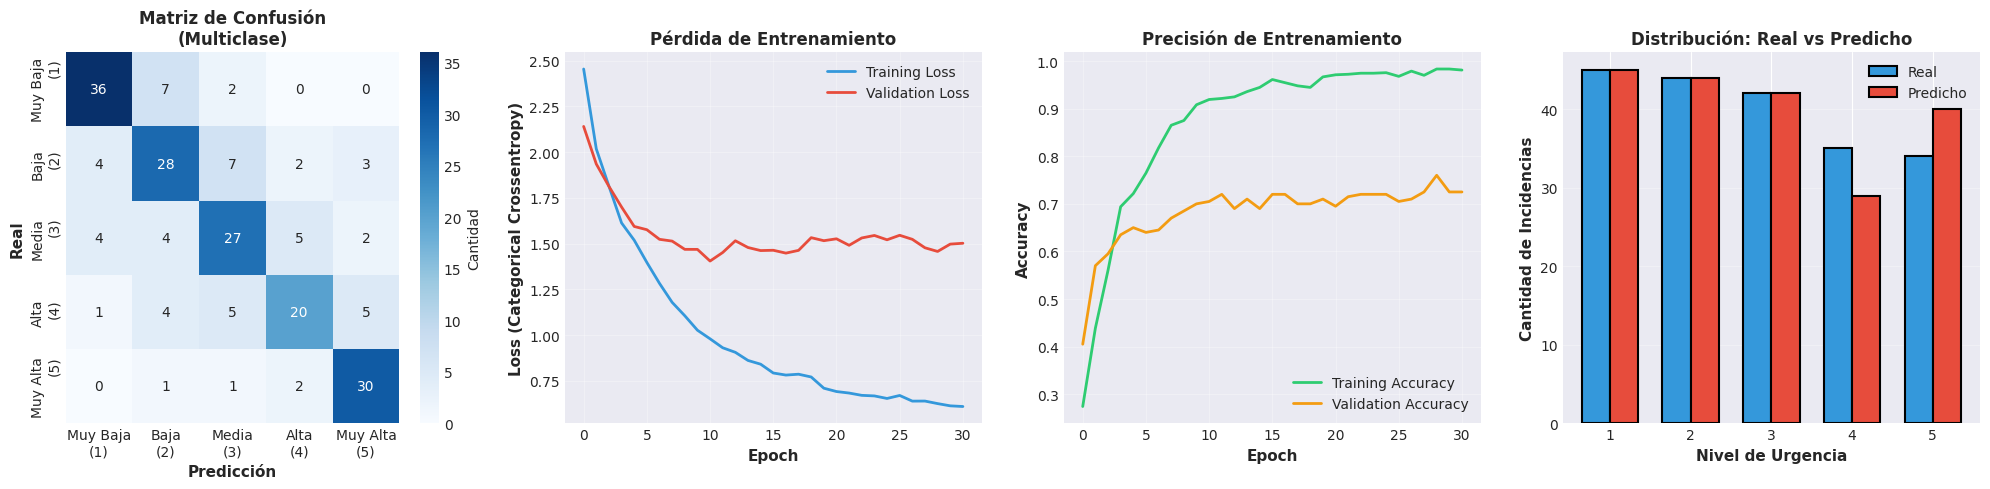


✓ Visualizaciones generadas exitosamente


In [22]:
# --- VISUALIZACIONES: MATRIZ DE CONFUSIÓN Y PÉRDIDA ---

# Crear figura con 4 subplots
fig = plt.figure(figsize=(20, 5))

# 1. Matriz de Confusión
ax1 = plt.subplot(1, 4, 1)
urgency_labels = ['Muy Baja\n(1)', 'Baja\n(2)', 'Media\n(3)', 'Alta\n(4)', 'Muy Alta\n(5)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=True,
            xticklabels=urgency_labels,
            yticklabels=urgency_labels,
            cbar_kws={'label': 'Cantidad'})
ax1.set_xlabel('Predicción', fontsize=11, fontweight='bold')
ax1.set_ylabel('Real', fontsize=11, fontweight='bold')
ax1.set_title('Matriz de Confusión\n(Multiclase)', fontsize=12, fontweight='bold')

# 2. Pérdida (Loss) durante el entrenamiento
ax2 = plt.subplot(1, 4, 2)
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2, color='#3498db')
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#e74c3c')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Loss (Categorical Crossentropy)', fontsize=11, fontweight='bold')
ax2.set_title('Pérdida de Entrenamiento', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Accuracy durante el entrenamiento
ax3 = plt.subplot(1, 4, 3)
ax3.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#2ecc71')
ax3.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#f39c12')
ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax3.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax3.set_title('Precisión de Entrenamiento', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Distribución de predicciones vs reales
ax4 = plt.subplot(1, 4, 4)
x_pos = np.arange(5)
width = 0.35

pred_counts = np.bincount(y_pred_urgencia, minlength=5)[1:]  # Urgencias 1-5
real_counts = np.bincount(y_test_urgencia, minlength=5)[1:]

ax4.bar(x_pos - width/2, real_counts, width, label='Real', color='#3498db', edgecolor='black', linewidth=1.5)
ax4.bar(x_pos + width/2, pred_counts, width, label='Predicho', color='#e74c3c', edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Nivel de Urgencia', fontsize=11, fontweight='bold')
ax4.set_ylabel('Cantidad de Incidencias', fontsize=11, fontweight='bold')
ax4.set_title('Distribución: Real vs Predicho', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['1', '2', '3', '4', '5'])
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ Visualizaciones generadas exitosamente")
print("="*80)


In [36]:
# --- FUNCIÓN DE PREDICCIÓN MEJORADA ---
def predecir_urgencia(descripcion, categoria):
    
    palabras_criticas = ['bomba', 'terrorista', 'asesinato', 'fuego', 'incendio', 'muerto', 'atropello', 'explosión', 'explosion', 'herido', 'violencia', 'robo con violencia', 'secuestro']
    
    # Filtro de seguridad (Override)
    if any(palabra in descripcion.lower() for palabra in palabras_criticas):
        return {
            'urgencia_predicha': 5,
            'confianza': 1.00, # 100% en formato float para que el .2% funcione
            'probabilidades': {
                'Urgencia_1': 0.0,
                'Urgencia_2': 0.0,
                'Urgencia_3': 0.0,
                'Urgencia_4': 0.0,
                'Urgencia_5': 1.0
            }
        }
    """
    Predice el nivel de urgencia usando la Red Neuronal (Clasificación Multiclase).
    
    MEJORAS IMPLEMENTADAS:
    - Texto procesado con BETO (BERT en español)
    - Modelo entrenado con SMOTE y class_weight
    - Arquitectura con Batch Normalization
    - Salida multiclase (5 probabilidades)
    
    Args:
        descripcion: Texto de la incidencia
        categoria: Categoría de la incidencia
    
    Returns:
        dict con:
            - urgencia_predicha: int (1-5)
            - confianza: float (probabilidad de la clase predicha)
            - probabilidades: dict con probabilidades para cada urgencia
    """
    # Validar que la categoría existe en el entrenamiento
    categorias_validas = df['categoria'].unique()
    if categoria not in categorias_validas:
        raise ValueError(f"Categoría '{categoria}' no válida. Opciones: {', '.join(categorias_validas)}")
    
    # 1. Transformar texto con BETO
    encoded = tokenizer(
        [descripcion],
        truncation=True,
        max_length=128,
        padding=True,
        return_tensors='pt'
    )
    # SOLUCIÓN: Apagar el cálculo de gradientes para la predicción
    with torch.no_grad():
        # Si usaste 'device' anteriormente, asegúrate de enviar los tensores allí
        outputs = beto_model(encoded['input_ids'].to(device), attention_mask=encoded['attention_mask'].to(device))
        
        # Como estamos en no_grad(), .numpy() ahora funciona perfectamente
        # (Añadimos .cpu() por si el modelo estuviera en GPU)
        text_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

    # 2. Transformar categoría a One-Hot
    cat_df = pd.DataFrame({'categoria': [categoria]})
    cat_encoded_full = pd.get_dummies(cat_df, columns=['categoria'], drop_first=True)
    cat_encoded = cat_encoded_full.reindex(columns=expected_cat_cols, fill_value=0).values

    # 3. Concatenar
    X_new = np.hstack((text_embedding, cat_encoded))

    # 4. Normalizar
    X_new_scaled = scaler.transform(X_new)

    # 5. Predecir con Red Neuronal (obtener probabilidades)
    pred_probs = nn_model.predict(X_new_scaled, verbose=0)[0]
    pred_class = np.argmax(pred_probs)
    urgencia_predicha = pred_class + 1

    # 6. Retornar resultados completos
    return {
        'urgencia_predicha': int(urgencia_predicha),
        'confianza': float(pred_probs[pred_class]),
        'probabilidades': {
            f'Urgencia_{i+1}': float(prob) 
            for i, prob in enumerate(pred_probs)
        }
    }

# --- PRUEBAS DE PREDICCIÓN ---
test_cases = [
    {
        "desc": "Una banda terrorista ha colocado una bomba en el centro comercial más grande de la ciudad.",
        "cat": "Otros"
    },
    {
        "desc": "Pintada en forma de rótulos obscenos en la pared de mi casa.",
        "cat": "Otros"
    },
    {
        "desc": "Falta el cambio de aceite en el alumbrado público.",
        "cat": "Limpieza"
    },
    {
        "desc": "Hay un socavón peligroso en la calle principal que podría causar un accidente grave.",
        "cat": "Movilidad"
    }
]

print("\n" + "="*80)
print("PRUEBAS DE PREDICCIÓN - MODELO MEJORADO")
print("="*80)

for i, case in enumerate(test_cases, 1):
    resultado = predecir_urgencia(case['desc'], case['cat'])
    
    print(f"\n📋 CASO {i}:")
    print(f"  Descripción: {case['desc'][:70]}...")
    print(f"  Categoría: {case['cat']}")
    print(f"  {'─'*78}")
    print(f"  Urgencia predicha: {resultado['urgencia_predicha']}/5")
    print(f"  Confianza: {resultado['confianza']:.2%}")
    print(f"  Probabilidades por urgencia:")
    for urg, prob in resultado['probabilidades'].items():
        bar_length = int(prob * 30)
        bar = '█' * bar_length + '░' * (30 - bar_length)
        print(f"    {urg}: [{bar}] {prob:.2%}")



PRUEBAS DE PREDICCIÓN - MODELO MEJORADO

📋 CASO 1:
  Descripción: Una banda terrorista ha colocado una bomba en el centro comercial más ...
  Categoría: Otros
  ──────────────────────────────────────────────────────────────────────────────
  Urgencia predicha: 5/5
  Confianza: 100.00%
  Probabilidades por urgencia:
    Urgencia_1: [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.00%
    Urgencia_2: [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.00%
    Urgencia_3: [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.00%
    Urgencia_4: [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.00%
    Urgencia_5: [██████████████████████████████] 100.00%

📋 CASO 2:
  Descripción: Pintada en forma de rótulos obscenos en la pared de mi casa....
  Categoría: Otros
  ──────────────────────────────────────────────────────────────────────────────
  Urgencia predicha: 1/5
  Confianza: 77.09%
  Probabilidades por urgencia:
    Urgencia_1: [███████████████████████░░░░░░░] 77.09%
    Urgencia_2: [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 4.53%
    Urgencia_3: [░░░░░░░░░░░

## ✅ Resumen del Modelo Final - Red Neuronal Mejorada (Clasificación Multiclase)

### 🎯 Cambio Principal: Regresión → Clasificación Multiclase
El modelo ahora predice 5 clases ordinales (urgencias 1-5) en lugar de valores continuos.

### 🏗️ Arquitectura Mejorada
- **Capas ocultas**: 256 → 128 → 64 → 32 → **5 (output)**
- **Batch Normalization**: Después de cada capa densa, antes de activación ReLU
- **Dropout**: 0.2 después de cada capa (excepto salida)
- **Regularización**: L2 (0.001) en todas las capas densas
- **Activación Salida**: **Softmax** (multiclase) - [MEJORA 1]
- **Optimizer**: Adam (learning_rate=0.001)
- **Loss**: **Categorical Crossentropy** (multiclase)

### 📝 Entrada de Texto Mejorada [MEJORA 2]
- **Método anterior**: TF-IDF Vectorizer
- **Método nuevo**: BETO (BERT en español, dccuchile/bert-base-spanish-wwm-uncased)
  - Dimensión: 768
  - Captura contexto semántico y orden de palabras
  - Pretrained en corpus español

### ⚖️ Gestión del Desbalanceo [MEJORA 4]
- **SMOTE**: Sobremuestreo de clases minoritarias
- **Class Weights**: Penalización mayor en clases 4 y 5
- **Estratificación**: En train/test split

### 🔄 Callbacks Avanzados [MEJORA 5]
- **EarlyStopping**: Detiene si val_loss no mejora (patience=20)
- **ReduceLROnPlateau**: Reduce learning rate dinámicamente (factor=0.5)

### 📊 Métricas de Evaluación [MEJORA 6]
- **Accuracy**: Exactitud de clasificación
- **MAE (Mean Absolute Error)**: Error promedio en escala ordinal
- **Quadratic Weighted Kappa**: Concordancia ponderada (penaliza errores grandes más)
- **Matriz de Confusión**: Análisis por clase

### 🚀 Mejoras Esperadas
- ✓ Predicciones más semánticas gracias a BETO
- ✓ Mejor manejo de clases desbalanceadas
- ✓ Modelos más estables con Batch Normalization
- ✓ Prevención de sobreajuste con callbacks avanzados
- ✓ Evaluación más realista con métricas ordinales
